<a href="https://colab.research.google.com/github/Sharvesh8326/24ADI003_24BAD110_ML/blob/main/24BAD110_EXP_2_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Sharvesh S
Roll No: 24BAD110
Scenario 1: Ocean Water Temperature Prediction

Available Columns:
 Index(['Cst_Cnt', 'Btl_Cnt', 'Sta_ID', 'Depth_ID', 'Depthm', 'T_degC',
       'Salnty', 'O2ml_L', 'STheta', 'O2Sat', 'Oxy_µmol/Kg', 'BtlNum',
       'RecInd', 'T_prec', 'T_qual', 'S_prec', 'S_qual', 'P_qual', 'O_qual',
       'SThtaq', 'O2Satq', 'ChlorA', 'Chlqua', 'Phaeop', 'Phaqua', 'PO4uM',
       'PO4q', 'SiO3uM', 'SiO3qu', 'NO2uM', 'NO2q', 'NO3uM', 'NO3q', 'NH3uM',
       'NH3q', 'C14As1', 'C14A1p', 'C14A1q', 'C14As2', 'C14A2p', 'C14A2q',
       'DarkAs', 'DarkAp', 'DarkAq', 'MeanAs', 'MeanAp', 'MeanAq', 'IncTim',
       'LightP', 'R_Depth', 'R_TEMP', 'R_POTEMP', 'R_SALINITY', 'R_SIGMA',
       'R_SVA', 'R_DYNHT', 'R_O2', 'R_O2Sat', 'R_SIO3', 'R_PO4', 'R_NO3',
       'R_NO2', 'R_NH4', 'R_CHLA', 'R_PHAEO', 'R_PRES', 'R_SAMP', 'DIC1',
       'DIC2', 'TA1', 'TA2', 'pH2', 'pH1', 'DIC Quality Comment'],
      dtype='object')

MSE: 7.095638897194017
RMSE: 2.6637640468318544
R2 Score: 0

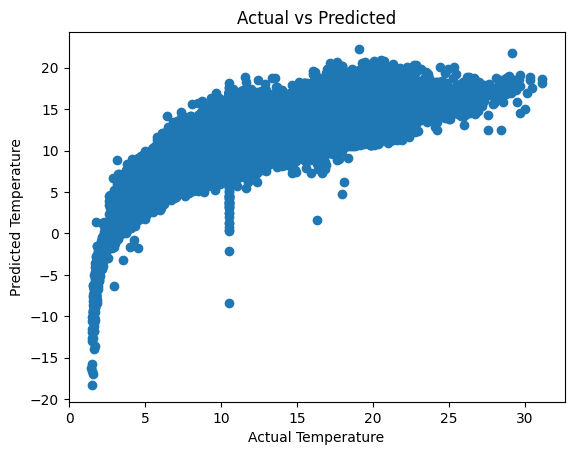

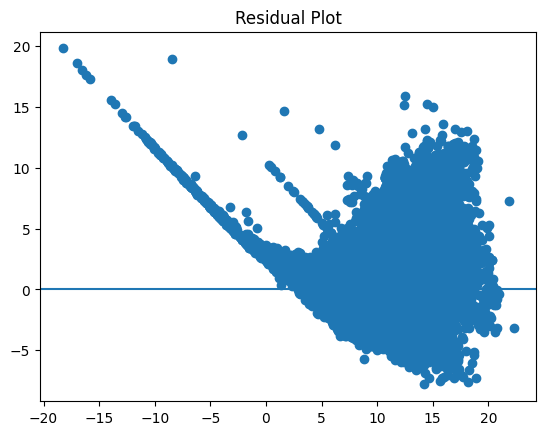

Ridge R2 Score: 0.6651187630059217


In [5]:
# Scenario 1:

print("Name: Sharvesh S")
print("Roll No: 24BAD110")
print("Scenario 1: Ocean Water Temperature Prediction\n")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

# Load dataset
df = pd.read_csv("bottle.csv")

# Print column names (to verify)
print("Available Columns:\n", df.columns)

# ✅ Use only columns that exist in most CalCOFI versions
features = ['Depthm', 'Salnty', 'O2ml_L']
target = 'T_degC'

# Keep only existing columns
available_features = [col for col in features if col in df.columns]

df = df[available_features + [target]]

# Handle missing values
imputer = SimpleImputer(strategy='mean')
df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

X = df[available_features]
y = df[target]

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nMSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

# Actual vs Predicted
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Actual vs Predicted")
plt.show()

# Residual Plot
residuals = y_test - y_pred
plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.title("Residual Plot")
plt.show()

# Ridge Regularization
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
print("Ridge R2 Score:", r2_score(y_test, ridge.predict(X_test)))

Name: Sharvesh S
Roll No: 24BAD110
Scenario 2: LIC Stock Movement Classification

Available Columns:
 Index(['date', 'open', 'high', 'low', 'close'], dtype='object')
Volume column not found
Accuracy: 0.8


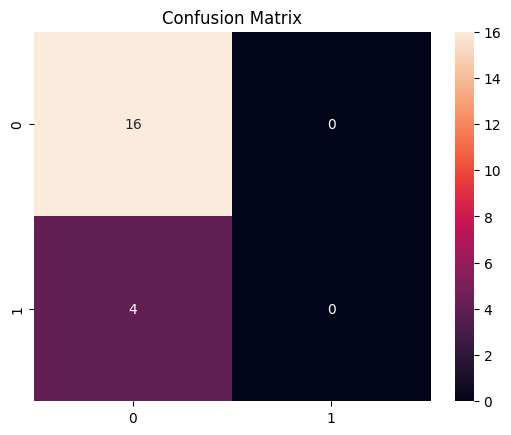

In [4]:
# Scenario 2: Logistic Regression (Fixed)

print("Name: Sharvesh S")
print("Roll No: 24BAD110")
print("Scenario 2: LIC Stock Movement Classification\n")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
df = pd.read_csv("LIC.csv")

# Clean column names (VERY IMPORTANT)
df.columns = df.columns.str.strip().str.lower()

print("Available Columns:\n", df.columns)

# Create target variable
df['price_movement'] = np.where(df['close'] > df['open'], 1, 0)

# Detect correct volume column automatically
if 'volume' in df.columns:
    volume_col = 'volume'
elif 'vol' in df.columns:
    volume_col = 'vol'
else:
    volume_col = None
    print("Volume column not found")

# Select features safely
features = ['open', 'high', 'low']
if volume_col:
    features.append(volume_col)

X = df[features]
y = df['price_movement']

# Handle missing values
X = X.fillna(X.mean())

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()